In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
import scipy.integrate as integrate

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
FIT = FitSpectrum()
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0315_dps_test.fits')

In [4]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())

Data loading and processing took 5.50 seconds.


In [5]:

example_id = 39627781868359233
example_idx = DP_SPECTRA.id2index(example_id)
lam = desi_wavelength / (1 + DP_SPECTRA.df.iloc[example_idx]['Z'])
flux, ivar = DP_SPECTRA.flux[example_idx], DP_SPECTRA.ivar[example_idx]
sigma = 1/np.sqrt(np.abs(ivar))

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_32313/588353551.py:5: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [6]:
display(DP_SPECTRA.df.iloc[example_idx])

TARGETID    39627781868359233
RA                 189.667677
DEC                 -0.128895
Z                    0.204595
SPECTYPE               GALAXY
LOGM                  9.15035
LOGSFR                1.28856
Name: 12617, dtype: object

In [7]:
line_cols = ['OII3729', 'OII3726',
            'Hbeta',
            'OIII5007', 'OIII4959',
            'Halpha', 'NII6583', 'NII6548',
            'SII6731', 'SII6716']

In [8]:
params_1comp, _, _, _ = FIT.fit_multi_emission_vel(data_class=DP_SPECTRA, id=example_id, two_component=False, w_dz=False)
params_2comp, _, _, _ = FIT.fit_multi_emission_vel(data_class=DP_SPECTRA, id=example_id, two_component=True, w_dz=False)


In [9]:
lams_1comp = []
flux_1comp = []

lams_2compL = []
flux_2compL = []

lams_2compR = []
flux_2compR = []

model_1comp = []
model_2compL = []
model_2compR = []
for i, amp in enumerate(params_1comp['amps']):
    for j in range(len(amp)):
        
        lams_1comp.append(params_1comp['lam0s'][i][j])
        flux_1comp.append(params_1comp['amps'][i][j]*np.sqrt(2*np.pi)*params_1comp['sigma']*params_1comp['lam0s'][i][j]/c)

        lams_2compL.append(params_2comp['left_lam0s'][i][j])
        flux_2compL.append(params_2comp['left_amps'][i][j]*np.sqrt(2*np.pi)*params_2comp['sigma_l']*params_2comp['left_lam0s'][i][j]*(1+params_2comp['dv_l']/c)/c)
        
        lams_2compR.append(params_2comp['right_lam0s'][i][j])
        flux_2compR.append(params_2comp['right_amps'][i][j]*np.sqrt(2*np.pi)*params_2comp['sigma_r']*params_2comp['right_lam0s'][i][j]*(1+params_2comp['dv_r']/c)/c)
        
        
        model_1comp.append(model_vel(lam, gaussian_parms=[(params_1comp['amps'][i][j], 
                                                           params_1comp['lam0s'][i][j], 
                                                           0, 
                                                           params_1comp['sigma'])]))
        model_2compL.append(model_vel(lam, gaussian_parms=[(params_2comp['left_amps'][i][j], 
                                                            params_2comp['left_lam0s'][i][j], 
                                                            params_2comp['dv_l'], 
                                                            params_2comp['sigma_l'])]))
        model_2compR.append(model_vel(lam, gaussian_parms=[(params_2comp['right_amps'][i][j], 
                                                            params_2comp['right_lam0s'][i][j], 
                                                            params_2comp['dv_r'], 
                                                            params_2comp['sigma_r'])]))
        

In [10]:
df_1comp = pd.DataFrame({'line': line_cols, 'lam0': lams_1comp, 'flux_1comp': np.array(flux_1comp).astype(np.float32)})
df_2comp = pd.DataFrame({'lam0': lams_2compL, 'flux_2compL': np.array(flux_2compL).astype(np.float32), 'flux_2compR': np.array(flux_2compR).astype(np.float32)})

df = pd.merge(df_1comp, df_2comp, on='lam0', how='outer').sort_values(by='lam0').reset_index(drop=True)
# df.index = df['line']
# df = df.transpose().iloc[1:]

df.head(10)

,line,lam0,flux_1comp,flux_2compL,flux_2compR
0,OII3726,3727.091749,156.357941,123.250893,27.477745
1,OII3729,3729.875470,208.111374,164.046112,36.572697
2,Hbeta,4862.691040,246.365692,199.286209,44.764774
3,OIII4959,4960.294948,208.286575,184.391418,27.960314
4,OIII5007,5008.239686,630.899414,558.521057,84.691711
5,NII6548,6549.859028,109.529221,92.133583,20.763403
6,Halpha,6564.631999,988.028381,803.351257,191.095337
7,NII6583,6585.278548,335.870636,282.527039,63.670837
8,SII6716,6718.294313,110.779312,81.905319,26.350115
9,SII6731,6732.668179,102.137619,82.288452,20.012217


In [11]:
df['flux_1comp']

0    156.357941
1    208.111374
2    246.365692
3    208.286575
4    630.899414
5    109.529221
6    988.028381
7    335.870636
8    110.779312
9    102.137619
Name: flux_1comp, dtype: float32

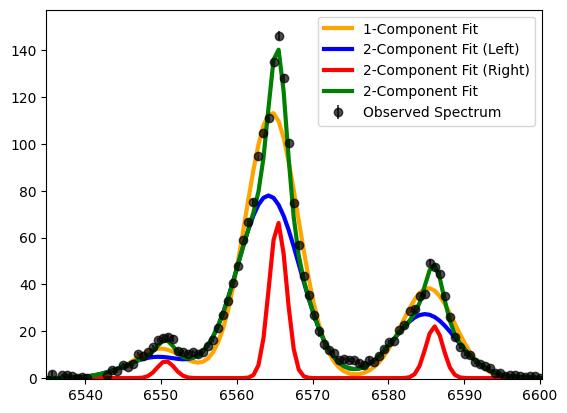

In [12]:
plt.errorbar(lam, flux, yerr=sigma, label='Observed Spectrum', fmt='o', color='k', alpha=0.7)
plt.plot(lam, np.sum(model_1comp, axis=0), label='1-Component Fit', color='orange', linewidth=3)
plt.plot(lam, np.sum(model_2compL, axis=0), label='2-Component Fit (Left)', color='blue', linewidth=3)
plt.plot(lam, np.sum(model_2compR, axis=0), label='2-Component Fit (Right)', color='red', linewidth=3)
plt.plot(lam, np.sum(model_2compL, axis=0)+np.sum(model_2compR, axis=0), label='2-Component Fit', color='green', linewidth=3)
plt.xlim((NII_rest[0]-15, NII_rest[1]+15))
plt.ylim(bottom=-0.5)
plt.legend()
plt.show()

In [13]:
def sfr(flux_halpha, flux_hbeta, z):
    """
    the unit of the flux is:
    1e-17 * erg / cm^2 / s
    """
    
    ebv = 1.97 * np.log10((flux_halpha/flux_hbeta) / 2.86)
    A_halpha = 3.33 * ebv
    flux_intrinsic = flux_halpha / (10**(A_halpha/-2.5)) * 1e-17
    flux_adjusted = flux_intrinsic * (1+z)
    
    luminous_distance = cosmo.luminosity_distance(z).to('cm').value
    lum_halpha = 4 * np.pi * (luminous_distance**2) * flux_adjusted
    sfr = 5.5e-42 * lum_halpha
    return sfr

In [14]:
sfr_1comp = sfr(df.iloc[6]['flux_1comp'], df.iloc[2]['flux_1comp'], DP_SPECTRA.df.iloc[example_idx]['Z'])
print(f' 1Comp: {np.log10(sfr_1comp)}')

sfr_2compL = sfr(df.iloc[6]['flux_2compL'], df.iloc[2]['flux_2compL'], DP_SPECTRA.df.iloc[example_idx]['Z'])
print(f'2CompL: {np.log10(sfr_2compL)}')

sfr_2compR = sfr(df.iloc[6]['flux_2compR'], df.iloc[2]['flux_2compR'], DP_SPECTRA.df.iloc[example_idx]['Z'])
print(f'2CompR: {np.log10(sfr_2compR)}')

print(f' 2Comp: {np.log10(sfr_2compL + sfr_2compR)}')

print(f'Cigale: {DP_SPECTRA.df.iloc[example_idx]['LOGSFR']}')

 1Comp: 1.3117901548087905
2CompL: 1.2278015841148158
2CompR: 0.6694467224271505
 2Comp: 1.3338115739265066
Cigale: 1.2885599568243102
